In [2]:
# trying out DAO Starfinder, following https://photutils.readthedocs.io/en/stable/getting_started.html

import numpy as np
from photutils.datasets import load_star_image
import matplotlib.pyplot as plt

hdu = load_star_image()
image = hdu.data[500:700, 500:700].astype(float)

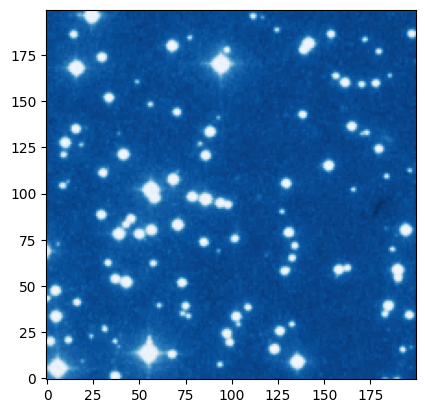

In [5]:
# show the imported image

plt.imshow(image, cmap='Blues_r', origin='lower')
%matplotlib inline

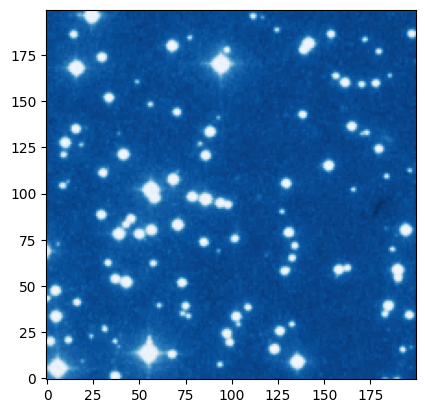

In [6]:
# remove the background from image median

removebg_image = image - np.median(image)
plt.imshow(removebg_image, cmap='Blues_r', origin='lower')
%matplotlib inline

In [34]:
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std

bkg_sigma = mad_std(removebg_image)  
daofind = DAOStarFinder(fwhm=4.0, threshold=3.0 * bkg_sigma)  
sources = daofind(removebg_image)  
for col in sources.colnames:  
    sources[col].info.format = '%.8g'  # for consistent table output
print(sources)  
print(bkg_sigma)

 id xcentroid ycentroid  sharpness  ... sky peak    flux       mag    
--- --------- ---------- ---------- ... --- ---- --------- -----------
  1 182.83866 0.16767019 0.85099873 ...   0 3824 2.8028346  -1.1189937
  2 189.20431 0.26081353  0.7400477 ...   0 4913 3.8729185  -1.4700959
  3 5.7946491  2.6125424 0.39589731 ...   0 7752 4.1029107  -1.5327302
  4 36.847063  1.3220228 0.29594528 ...   0 8739 7.4315818  -2.1777032
  5 3.2565602   5.418952 0.35985495 ...   0 6935 3.8126298  -1.4530616
  6 10.268038  5.3999204 0.49375848 ...   0 8205 2.8472517  -1.1360646
  7 93.556424  7.3860242 0.50812587 ...   0 7440 7.0356171  -2.1182555
  8 5.7380557  7.5152239 0.44193256 ...   0 8500 2.7201818  -1.0864948
  9 19.136489   9.040662 0.68910946 ...   0 3691 2.7049518  -1.0803988
 10 55.052002  11.353116 0.43075296 ...   0 8115 2.9139911  -1.1612205
...       ...        ...        ... ... ...  ...       ...         ...
143 171.90254  183.06103 0.51580185 ...   0 7587 7.9533704   -2.251378
144 77

In [8]:
from photutils.aperture import aperture_photometry, CircularAperture
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))  
apertures = CircularAperture(positions, r=4.0)  
phot_table = aperture_photometry(removebg_image, apertures)  
for col in phot_table.colnames:  
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)  

 id  xcenter   ycenter   aperture_sum
       pix       pix                 
--- --------- ---------- ------------
  1 182.83866 0.16767019    18121.759
  2 189.20431 0.26081353    29836.515
  3 5.7946491  2.6125424    331979.82
  4 36.847063  1.3220228    183705.09
  5 3.2565602   5.418952    349468.98
  6 10.268038  5.3999204    261533.37
  7 93.556424  7.3860242     66815.03
  8 5.7380557  7.5152239    363004.57
  9 19.136489   9.040662    49273.929
...       ...        ...          ...
143 171.90254  183.06103    47904.419
144 77.248199  184.02735    54903.417
145 14.510474  185.86368    143839.37
146 153.55621  185.96483    142561.83
147 197.24864  186.16647    137269.81
148 124.31327  188.30523    45084.874
149 24.257207  194.71494    355778.01
150    116.45  195.05923    31232.912
151 18.958086  196.34207    162076.26
152 111.52575  195.73192    82795.715
Length = 152 rows


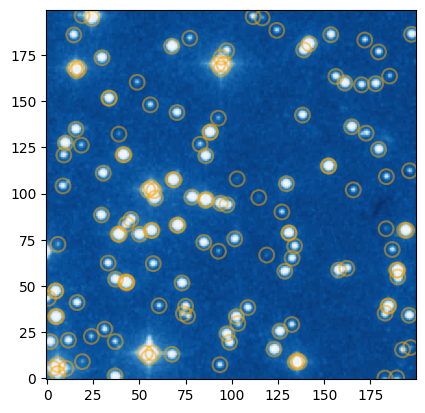

In [9]:
import matplotlib.pyplot as plt
plt.imshow(removebg_image, cmap='Blues_r', origin='lower')
apertures.plot(color='orange', lw=1.5, alpha=0.5)
%matplotlib inline

In [10]:
# trying this with TESS tpfs
import lightkurve as lk

def getData(ra:float, dec:float, sectorno:int):
    location = str(ra) + ", " + str(dec)
    search_result = lk.search_tesscut(location, sector=sectorno)
    tpf = search_result.download(cutout_size=60)
    return tpf

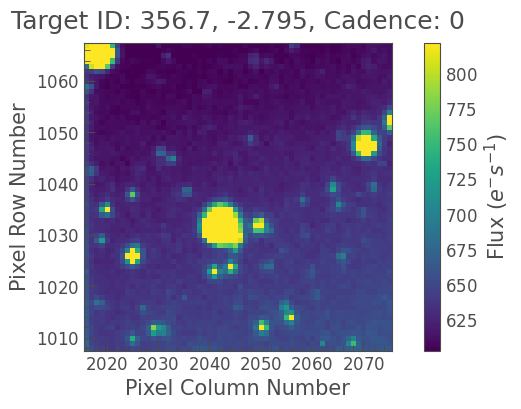

In [11]:
lower_tpf = getData(356.7, -2.795, 70)
lower_tpf.plot();
%matplotlib inline

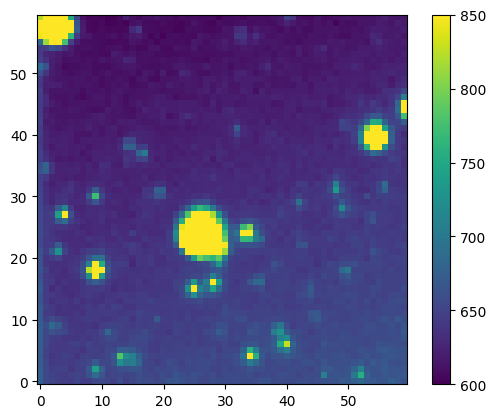

In [12]:
lwr_c0 = lower_tpf.hdu[1].data['FLUX'][0]

fig, ax = plt.subplots()
cax = ax.imshow(lwr_c0, origin='lower', cmap='viridis', vmin = 600, vmax=850)
plt.colorbar(cax, ax=ax)
%matplotlib inline

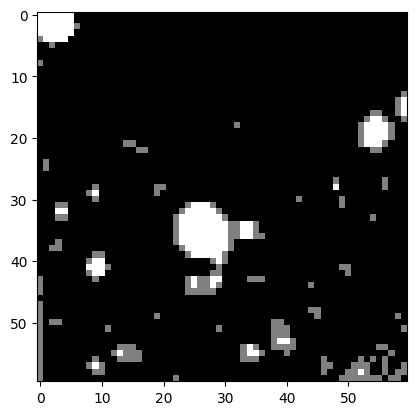

(60, 60, 4)

In [61]:
import matplotlib.image as mpimg

scaled_data = (lwr_c0 - np.min(lwr_c0)) / (np.max(lwr_c0) - np.min(lwr_c0)) * 255
scaled_data = scaled_data.astype(np.uint8)  # Convert to uint8 for PNG

# Step 4: Save the pixel values as a PNG file
png_filename = 'output.png'
plt.imsave(png_filename, scaled_data, cmap='gray', origin='lower', vmin=0, vmax=2)  # Save as grayscale PNG
img = mpimg.imread(png_filename)

plt.imshow(img, cmap='gray')  # Assuming the image is grayscale
plt.show()
img.shape

In [47]:
scaled_data = img[..., :3]

# Convert RGB to grayscale using luminance formula: Y = 0.299*R + 0.587*G + 0.114*B
grayscale_img = np.dot(scaled_data[...,:3], [0.299, 0.587, 0.114])

# Now grayscale_img is a 2D array representing the grayscale image
print(grayscale_img.shape)

(60, 60)


In [15]:
removebg_lower_image = lower_image - np.median(lower_image)
plt.imshow(removebg_lower_image, cmap='Blues_r', origin='lower')
%matplotlib inline

NameError: name 'lower_image' is not defined

In [55]:
from astropy.stats import sigma_clipped_stats

bkg_sigma = mad_std(grayscale_img)  
daofind = DAOStarFinder(fwhm=4.0, threshold=100.0 * bkg_sigma)  
sources = daofind(grayscale_img)  
for col in sources.colnames:  
    sources[col].info.format = '%.8g'  # for consistent table output
print(sources)  
print(bkg_sigma)

 id   xcentroid    ycentroid sharpness  ... sky    peak    flux mag 
--- -------------- --------- ---------- ... --- ---------- ---- ----
  1      1.5704267 1.5704267 0.24378076 ...   0          1  inf -inf
  2      3.4295733 1.6250198 0.24775511 ...   0          1  inf -inf
  3      58.763008        15 0.55791265 ...   0          1  inf -inf
  4      54.402625        19 0.40806863 ...   0          1  inf -inf
  5      54.286031 19.439681  0.4406594 ...   0          1  inf -inf
  6             48 27.956125  0.7475799 ...   0 0.50196081  inf -inf
  7      19.319769 28.319769 0.74565818 ...   0 0.50196081  inf -inf
  8      8.8358416        29 0.88590094 ...   0          1  inf -inf
  9      3.5165559        32 0.62595553 ...   0          1  inf -inf
 10      3.4834441        32 0.62595553 ...   0          1  inf -inf
...            ...       ...        ... ... ...        ...  ...  ...
 20 -4.5687618e-17        44 0.74565818 ...   0 0.50196081  inf -inf
 21      25.257531 43.867357 0.512

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\photutils\detection\daofinder.py:640: RuntimeWarning: divide by zero encountered in divide
  return ((self.convdata_peak / self.threshold_eff)


In [56]:
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))  
apertures = CircularAperture(positions, r=4.0)  
phot_table = aperture_photometry(grayscale_img, apertures)  
for col in phot_table.colnames:  
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)  

 id    xcenter      ycenter  aperture_sum
         pix          pix                
--- -------------- --------- ------------
  1      1.5704267 1.5704267    28.515944
  2      3.4295733 1.6250198    28.564946
  3      58.763008        15    7.4205113
  4      54.402625        19    24.027648
  5      54.286031 19.439681    24.011857
  6             48 27.956125    2.5058824
  7      19.319769 28.319769    1.5058824
  8      8.8358416        29    2.5058824
  9      3.5165559        32    4.0078433
...            ...       ...          ...
 20 -4.5687618e-17        44    2.2535826
 21      25.257531 43.867357    11.188968
 22      44.680231 48.319769    1.5616258
 23       39.39992 52.876788    9.7703559
 24      55.767214 54.864726    5.3857988
 25      34.229143  54.88413    6.9472436
 26       9.105156 57.105156    4.2622472
 27      46.231556        57    2.8975733
 28      51.910991 57.978774    8.8794791
 29      57.847534 58.129282    5.3510036
Length = 29 rows


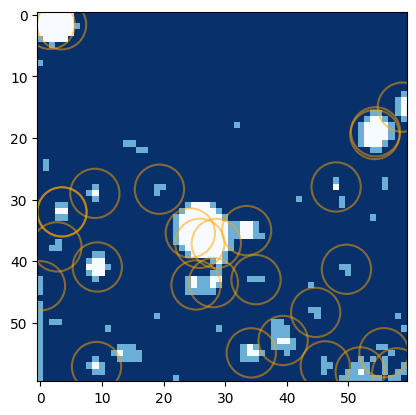

In [57]:
import matplotlib.pyplot as plt
plt.imshow(grayscale_img, cmap='Blues_r')
apertures.plot(color='orange', lw=1.5, alpha=0.5)
%matplotlib inline

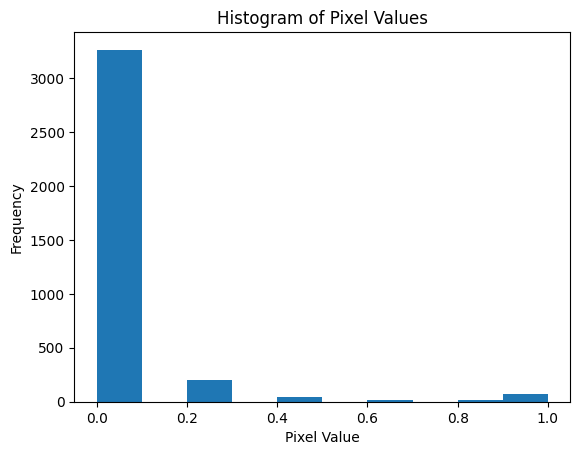

In [45]:
#debugging, histogram of brightness values

plt.hist(grayscale_img.ravel(), bins=10, range=[0, 1])
plt.title('Histogram of Pixel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# lets try this: https://youtu.be/vxMoG2K_n5o?feature=shared

# After discussion, this might not be effective.